# MIMIC-IV 30-Day Readmission Prediction
## Notebook 3: Modeling

This notebook trains and evaluates predictive models for 30-day hospital 
readmission. We follow a rigorous ML pipeline:
1. Temporal train/test split (no data leakage)
2. Logistic regression baseline
3. XGBoost with class imbalance handling
4. Hyperparameter tuning with cross-validation
5. Feature importance analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')

print("Libraries loaded successfully")
print(f"XGBoost version: {xgb.__version__}")

Libraries loaded successfully
XGBoost version: 3.2.0


In [2]:
print("Loading feature matrix...")
feature_matrix = pd.read_csv(DATA_DIR / 'feature_matrix.csv')

with open(DATA_DIR / 'feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

# Also load cohort for temporal split
cohort = pd.read_csv(DATA_DIR / 'cohort_base.csv', 
                     parse_dates=['admittime', 'dischtime'])

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Target distribution:")
print(feature_matrix['readmitted_30'].value_counts())
print(f"Readmission rate: {feature_matrix['readmitted_30'].mean():.1%}")

Loading feature matrix...
Feature matrix shape: (534152, 47)
Number of features: 45
Target distribution:
readmitted_30
0    441397
1     92755
Name: count, dtype: int64
Readmission rate: 17.4%


In [3]:
print("=== TEMPORAL TRAIN/TEST SPLIT ===")

# Load cohort with admittime to get temporal ordering
cohort_full = pd.read_csv(DATA_DIR / 'cohort_base.csv',
                          parse_dates=['admittime'])

# Sort by admission time
cohort_full = cohort_full.sort_values('admittime').reset_index(drop=True)

# Use 80/20 temporal split
cutoff_idx = int(len(cohort_full) * 0.8)
cutoff_date = cohort_full.iloc[cutoff_idx]['admittime']
print(f"Training cutoff date: {cutoff_date}")

train_hadm_ids = set(
    cohort_full[cohort_full['admittime'] <= cutoff_date]['hadm_id']
)
test_hadm_ids = set(
    cohort_full[cohort_full['admittime'] > cutoff_date]['hadm_id']
)

print(f"Train admissions: {len(train_hadm_ids):,}")
print(f"Test admissions: {len(test_hadm_ids):,}")

=== TEMPORAL TRAIN/TEST SPLIT ===
Training cutoff date: 2179-03-20 20:17:00
Train admissions: 427,382
Test admissions: 106,845


In [4]:
# Add hadm_id to feature matrix using cohort ordering
# Match rows by position - feature matrix rows correspond to 
# cohort_base rows after the same filtering we applied

# Load cohort and apply same filters as notebook 2
cohort_ordered = pd.read_csv(DATA_DIR / 'cohort_base.csv',
                             parse_dates=['admittime', 'dischtime'])

# Compute los_days the same way as notebook 2
cohort_ordered['los_days'] = (
    cohort_ordered['dischtime'] - cohort_ordered['admittime']
).dt.total_seconds() / (24 * 3600)

# Apply same filters as notebook 2
cohort_ordered = cohort_ordered[cohort_ordered['los_days'] >= 0].copy()
cohort_ordered = cohort_ordered[cohort_ordered['los_days'] <= 365].copy()
cohort_ordered = cohort_ordered.reset_index(drop=True)

print(f"Cohort rows after filtering: {len(cohort_ordered):,}")
print(f"Feature matrix rows: {len(feature_matrix):,}")

# Verify lengths match
assert len(cohort_ordered) == len(feature_matrix), \
    f"Length mismatch: cohort={len(cohort_ordered)}, features={len(feature_matrix)}"

# Add hadm_id to feature matrix
feature_matrix['hadm_id'] = cohort_ordered['hadm_id'].values

# Split into train and test
train_mask = feature_matrix['hadm_id'].isin(train_hadm_ids)
test_mask = feature_matrix['hadm_id'].isin(test_hadm_ids)

train_df = feature_matrix[train_mask].copy()
test_df = feature_matrix[test_mask].copy()

print(f"\nTrain set: {len(train_df):,} admissions")
print(f"Test set: {len(test_df):,} admissions")
print(f"Train readmission rate: {train_df['readmitted_30'].mean():.1%}")
print(f"Test readmission rate: {test_df['readmitted_30'].mean():.1%}")

# Create X and y arrays
X_train = train_df[feature_cols].values
y_train = train_df['readmitted_30'].values
X_test = test_df[feature_cols].values
y_test = test_df['readmitted_30'].values

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Cohort rows after filtering: 534,152
Feature matrix rows: 534,152

Train set: 427,321 admissions
Test set: 106,831 admissions
Train readmission rate: 17.2%
Test readmission rate: 18.1%

X_train shape: (427321, 45)
X_test shape: (106831, 45)


In [5]:
print("=== LOGISTIC REGRESSION BASELINE ===")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
lr = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)
lr.fit(X_train_scaled, y_train)

# Evaluate
lr_train_probs = lr.predict_proba(X_train_scaled)[:, 1]
lr_test_probs = lr.predict_proba(X_test_scaled)[:, 1]

lr_train_auc = roc_auc_score(y_train, lr_train_probs)
lr_test_auc = roc_auc_score(y_test, lr_test_probs)
lr_test_ap = average_precision_score(y_test, lr_test_probs)

print(f"Logistic Regression Results:")
print(f"  Train AUC-ROC: {lr_train_auc:.4f}")
print(f"  Test AUC-ROC:  {lr_test_auc:.4f}")
print(f"  Test AP Score: {lr_test_ap:.4f}")

=== LOGISTIC REGRESSION BASELINE ===
Logistic Regression Results:
  Train AUC-ROC: 0.6437
  Test AUC-ROC:  0.6317
  Test AP Score: 0.2651


In [6]:
print("=== XGBOOST MODEL ===")

# Calculate scale_pos_weight for class imbalance
# ratio of negative to positive examples
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print(f"(ratio of negative to positive training examples)")

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

# Evaluate
xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

xgb_train_auc = roc_auc_score(y_train, xgb_train_probs)
xgb_test_auc = roc_auc_score(y_test, xgb_test_probs)
xgb_test_ap = average_precision_score(y_test, xgb_test_probs)

print(f"\nXGBoost Results:")
print(f"  Train AUC-ROC: {xgb_train_auc:.4f}")
print(f"  Test AUC-ROC:  {xgb_test_auc:.4f}")
print(f"  Test AP Score: {xgb_test_ap:.4f}")
print(f"  Best iteration: {xgb_model.best_iteration}")

=== XGBOOST MODEL ===
scale_pos_weight: 4.82
(ratio of negative to positive training examples)
[0]	validation_0-auc:0.63734	validation_1-auc:0.62943
[50]	validation_0-auc:0.67511	validation_1-auc:0.65866
[100]	validation_0-auc:0.68355	validation_1-auc:0.66269
[150]	validation_0-auc:0.69036	validation_1-auc:0.66527
[200]	validation_0-auc:0.69564	validation_1-auc:0.66697
[250]	validation_0-auc:0.70018	validation_1-auc:0.66811
[300]	validation_0-auc:0.70436	validation_1-auc:0.66878
[350]	validation_0-auc:0.70827	validation_1-auc:0.66923
[400]	validation_0-auc:0.71208	validation_1-auc:0.66976
[438]	validation_0-auc:0.71483	validation_1-auc:0.66983

XGBoost Results:
  Train AUC-ROC: 0.7134
  Test AUC-ROC:  0.6700
  Test AP Score: 0.3074
  Best iteration: 418


In [7]:
print("=== MODEL COMPARISON ===")

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Train AUC-ROC': [lr_train_auc, xgb_train_auc],
    'Test AUC-ROC': [lr_test_auc, xgb_test_auc],
    'Test AP Score': [lr_test_ap, xgb_test_ap]
})

print(results.to_string(index=False))

improvement = (xgb_test_auc - lr_test_auc) / lr_test_auc * 100
print(f"\nXGBoost improvement over LR: {improvement:.1f}%")

=== MODEL COMPARISON ===
              Model  Train AUC-ROC  Test AUC-ROC  Test AP Score
Logistic Regression         0.6437        0.6317         0.2651
            XGBoost         0.7134        0.6700         0.3074

XGBoost improvement over LR: 6.1%


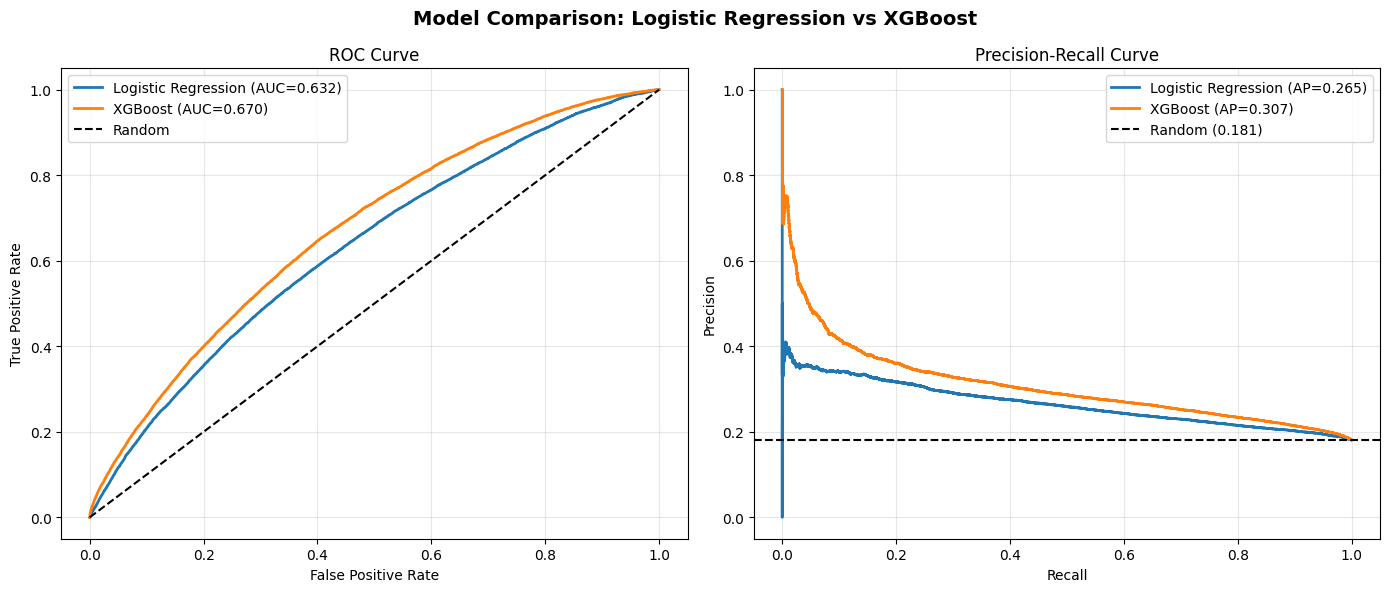

Figure saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax = axes[0]
for name, probs in [('Logistic Regression', lr_test_probs), 
                     ('XGBoost', xgb_test_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
for name, probs in [('Logistic Regression', lr_test_probs),
                     ('XGBoost', xgb_test_probs)]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)

ax.axhline(y=y_test.mean(), color='k', linestyle='--', 
           label=f'Random ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Logistic Regression vs XGBoost', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

=== XGBOOST FEATURE IMPORTANCE ===
Top 20 most important features:
                            feature  importance
                    discloc_HOSPICE      0.1202
               admtype_DIRECT EMER.      0.0986
             discloc_PSYCH FACILITY      0.0538
                  insurance_Private      0.0426
                   admtype_ELECTIVE      0.0421
                      n_medications      0.0392
             admtype_EU OBSERVATION      0.0390
admtype_SURGICAL SAME DAY ADMISSION      0.0348
           discloc_HOME HEALTH CARE      0.0338
                     admtype_URGENT      0.0310
         admtype_DIRECT OBSERVATION      0.0278
                         has_opioid      0.0230
                  has_renal_failure      0.0217
                        n_diagnoses      0.0213
                      gender_binary      0.0211
                      discloc_REHAB      0.0211
             discloc_AGAINST ADVICE      0.0206
                  has_anticoagulant      0.0195
                     

<Figure size 1000x800 with 0 Axes>

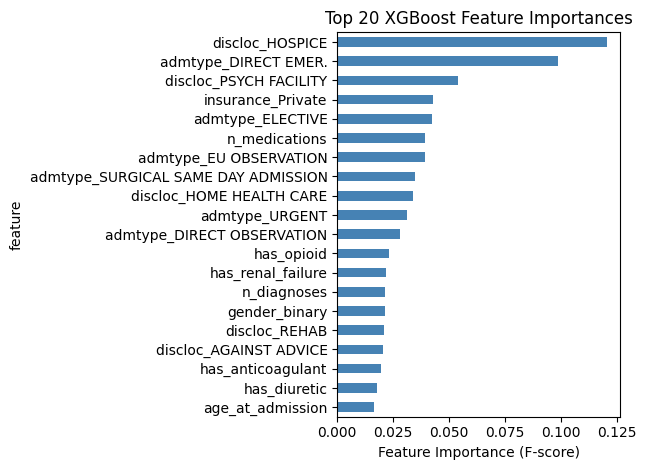

Figure saved


In [9]:
print("=== XGBOOST FEATURE IMPORTANCE ===")

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(importance_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
importance_df.head(20).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', 
    legend=False, color='steelblue'
)
plt.xlabel('Feature Importance (F-score)')
plt.title('Top 20 XGBoost Feature Importances')
plt.tight_layout()
plt.savefig('../figures/xgb_feature_importance.png', dpi=150)
plt.show()
print("Figure saved")

In [10]:
import pickle

# Save model
with open(DATA_DIR / 'xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open(DATA_DIR / 'lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open(DATA_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save test predictions for notebook 4
test_results = pd.DataFrame({
    'hadm_id': test_df['hadm_id'].values,
    'y_true': y_test,
    'lr_prob': lr_test_probs,
    'xgb_prob': xgb_test_probs
})
test_results.to_csv(DATA_DIR / 'test_predictions.csv', index=False)

# Save results summary
results.to_csv(DATA_DIR / 'model_results.csv', index=False)

print("Models and predictions saved")
print(f"\nFinal Results Summary:")
print(results.to_string(index=False))

Models and predictions saved

Final Results Summary:
              Model  Train AUC-ROC  Test AUC-ROC  Test AP Score
Logistic Regression         0.6437        0.6317         0.2651
            XGBoost         0.7134        0.6700         0.3074
